### Importing the required dependency

In [1]:
import random
import math
import numpy as np
from deap import base, creator, tools, gp
import operator

In [2]:
# Defining the Population size for the Genetic Programming
POPULATION_SIZE = 1000
# Defining the number of generations for the Genetic Algorithm
NUM_OF_GENERATION = 50
# Defining the mutation rate for the child to be mutated
MUTATION_RATE = 0.15
# Calculating the elite size based on the population size, ensuring it is at least 5
ELITE_SIZE = max(5, int(0.05 * POPULATION_SIZE))
# Initialization: Minimum Depth of Tree
INIT_MIN_DEPTH = 2
# Initialization: Maximum Depth of Tree
INIT_MAX_DEPTH = 6
# Mutation: Minimum Depth of Tree
MUT_MIN_DEPTH = 0
# Mutation: Maximum Depth of Tree
MUT_MAX_DEPTH = 2
# Maximum allowed height of GP tree
MAX_HEIGHT = 8
# Maximum number of node in the GP tree
MAX_NUM_OF_NODE = 50

### Evaluation Function 

In [3]:
# Helper Function to create training instances
def target_function(x):
    if x > 0:
        return (1 / x) + math.sin(x)
    else:
        return 2 * x + x**2 + 3.0

# Taking random points
points = [x for x in np.arange(-5, 5.1, 0.1) if abs(x) > 1e-6]

# List of Tuple storing (x,y) value for the GP expression
fitness_cases = [(x, target_function(x)) for x in points]

# Evaluation function for Symbolic Regression
def evaluate_symbolic_regression(individual):
    func = toolbox.compile(expr=individual)

    squared_errors = []

    for x, y in fitness_cases:
        try:
            prediction = func(x)

            # Check for invalid numerical results
            if not math.isfinite(prediction):
                return (float("inf"),)

            squared_error = (prediction - y) ** 2
            squared_errors.append(squared_error)

        except (ValueError, OverflowError, ZeroDivisionError):
            return (float("inf"),)

    # Mean Squared Error
    mse = math.fsum(squared_errors) / len(squared_errors)

    return (mse,)

### Symbolic Regression using GP

##### Function and Terminal Set

In [4]:
# Protected Division
def protectedDiv(left, right):
    if abs(right) < 1e-6:
        return 1.0
    return left / right

# Helper function to generate random constants 
def generate_constant():
    return random.uniform(-5, 5)

    
# Function Set
pset = gp.PrimitiveSet("MAIN", 1)
pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)
pset.addPrimitive(protectedDiv, 2)
pset.addPrimitive(math.sin, 1)
pset.addPrimitive(math.cos, 1)
pset.addPrimitive(abs, 1)

# Terminal Set
pset.addEphemeralConstant("rand_const", generate_constant)
pset.renameArguments(ARG0='x')

In [5]:
# Creating Fitness and Individual Class
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)

# Registering function with the toolbox
toolbox = base.Toolbox()

# Individual
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=INIT_MIN_DEPTH, max_=INIT_MAX_DEPTH)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)

# Population
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Compilation
toolbox.register("compile", gp.compile, pset=pset)

# Evaluation
toolbox.register("evaluate", evaluate_symbolic_regression)

# Selection strategy: Tournament selection
toolbox.register("select", tools.selTournament, tournsize=3)

# Crossover Strategy: One point crossover
toolbox.register("crossover", gp.cxOnePoint)

# Mutation
toolbox.register("expr_mut", gp.genFull, min_=MUT_MIN_DEPTH, max_=MUT_MAX_DEPTH)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

# Limiting the maximum height and number of nodes after crossover and mutation
toolbox.decorate(
    "crossover",
    gp.staticLimit(
        key=operator.attrgetter("height"),
        max_value=MAX_HEIGHT
    )
)

toolbox.decorate(
    "crossover",
    gp.staticLimit(
        key=len,
        max_value=MAX_NUM_OF_NODE
    )
)

toolbox.decorate(
    "mutate",
    gp.staticLimit(
        key=operator.attrgetter("height"),
        max_value=MAX_HEIGHT
    )
)

toolbox.decorate(
    "mutate",
    gp.staticLimit(
        key=len,
        max_value=MAX_NUM_OF_NODE
    )
)

##### Algorithm for GP

In [6]:
# Seed list for 3 random GA runs
ga_seeds_list = [42, 52, 62]

best_gp_individuals = []

# Iterating through each GA run with different seeds
for ga_index, ga_seed in enumerate(ga_seeds_list):
    # Setting the seed using an integer
    random.seed(ga_seed)

    # Initializing a initial population
    initial_population = toolbox.population(POPULATION_SIZE)

    # Evaluating fitness for each individual
    for individual in initial_population:
            individual.fitness.values = toolbox.evaluate(individual)

    # Iterating through each generation for the current GA run
    for gen_index in range(NUM_OF_GENERATION):
        # Creating a new population for the next generation
        new_population = list()
        
        # Performing Elitism so that we have the best individual carried forward
        elites = tools.selBest(initial_population, ELITE_SIZE)
        elites = list(map(toolbox.clone, elites))
        new_population.extend(elites)

        # Till the new population is filled to the required size, perform selection, crossover, and mutation
        while(len(new_population)<POPULATION_SIZE):
            # Selection: K-Tournament approach - choose two individual for crossover
            offspring = toolbox.select(individuals = initial_population, k = 2)
            # Clone the selected individuals
            [parent1, parent2] = map(toolbox.clone, offspring)
            
            # Crossover: One Point crossover approach
            [child1, child2] = toolbox.crossover(parent1, parent2)
            
            # Mutation
            if random.random() < MUTATION_RATE:
                child1 = toolbox.mutate(child1)[0]
            if random.random() < MUTATION_RATE:
                child2 = toolbox.mutate(child2)[0]

            # Evaluating the fitness of the newly created children
            child1.fitness.values = toolbox.evaluate(child1)
            child2.fitness.values = toolbox.evaluate(child2)


            # Adding only if the new population is not yet filled to the required size
            if (len(new_population) < POPULATION_SIZE):
                new_population.append(child1)
                
            if (len(new_population) < POPULATION_SIZE):
                new_population.append(child2)

        # Updating the initial population for the next generation
        initial_population = new_population

    # Finding best inidvidual for a particulat GA run and finding modal accuracy for that
    best_individual = tools.selBest(new_population, 1)[0]
    best_gp_individuals.append(best_individual)
    
    # DEBUG LOG(Uncomment to see result): Printing the best individual and its fitness for the current GA run 
    print(f'GA Index: {ga_index + 1}, Fitness value: {best_individual.fitness.values[0]}, Best Individual: {best_individual}, Node: {len(best_individual)}')

GA Index: 1, Fitness value: 0.4516206157652573, Best Individual: abs(add(protectedDiv(protectedDiv(protectedDiv(x, sub(4.384844795887625, 2.6526076547520177)), abs(sub(abs(protectedDiv(x, -2.3411794835130886)), x))), x), protectedDiv(sub(abs(protectedDiv(abs(add(x, 0.5921058631158438)), -2.3411794835130886)), add(x, -2.1335187445801216)), abs(abs(protectedDiv(abs(abs(2.7565966338547536)), abs(x))))))), Node: 37
GA Index: 2, Fitness value: 0.6823808233314226, Best Individual: add(abs(sub(sub(x, protectedDiv(sin(sin(sub(-4.1049490216917786, -1.3680828926840571))), protectedDiv(x, sub(add(x, 1.190670649756301), abs(x))))), sub(-4.1049490216917786, -1.3680828926840571))), mul(x, mul(protectedDiv(0.661963066487786, 1.190670649756301), sub(cos(add(x, 1.190670649756301)), abs(abs(x)))))), Node: 36
GA Index: 3, Fitness value: 0.27739392083542763, Best Individual: mul(protectedDiv(sub(x, abs(3.393269821299814)), 3.8202359449297845), sub(x, abs(sub(sub(sin(sin(3.8202359449297845)), protectedDiv(

### Plotting

In [7]:
import matplotlib.pyplot as plt

def plot_area(plot_label, x_values):
    # Original function values
    original_y = [
        target_function(x)
        for x in x_values
    ]
    
    # Create plot
    plt.figure(figsize=(12, 7))
    
    # Original target function
    plt.plot(x_values, original_y, label="Original Function", linewidth=3)
    
    # Plot the 3 best GP programs
    for index, individual in enumerate(best_gp_individuals):
        # Convert GP tree into callable function
        func = toolbox.compile(expr=individual)
    
        gp_y = []
    
        for x in x_values:
            try:
                prediction = func(x)
    
                # Avoid invalid values
                if not math.isfinite(prediction):
                    gp_y.append(np.nan)
                else:
                    gp_y.append(prediction)
    
            except (ValueError, OverflowError, ZeroDivisionError):
                gp_y.append(np.nan)
        plt.plot(x_values, gp_y, label=f"GP Run {index + 1}")
    
    
    # Adding labels
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title(plot_label)
    plt.legend()
    plt.grid(True)
    
    plt.show()

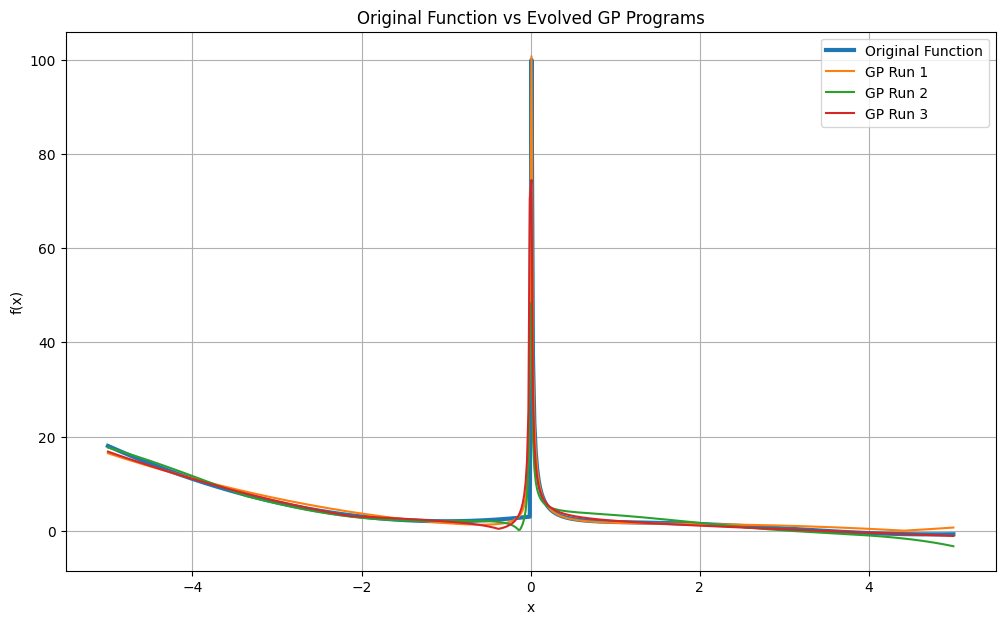

In [8]:
# X values
x_values = np.concatenate([
    np.linspace(-5, -0.01, 300),
    np.linspace(0.01, 5, 300)
])

plot_area("Original Function vs Evolved GP Programs", x_values)

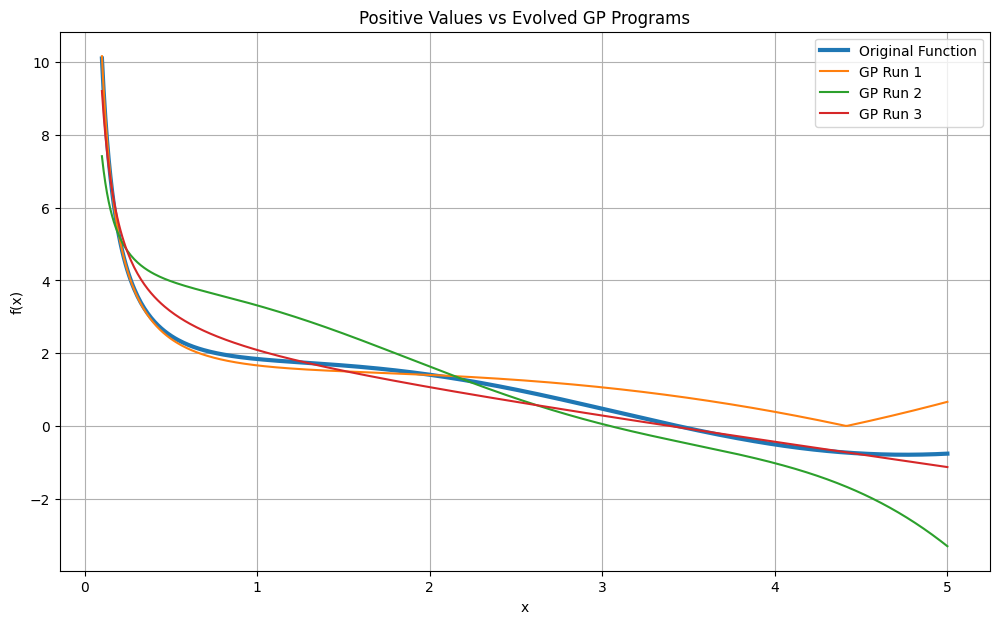

In [9]:
x_positive = np.linspace(0.1, 5, 500)
plot_area("Positive Values vs Evolved GP Programs", x_positive)

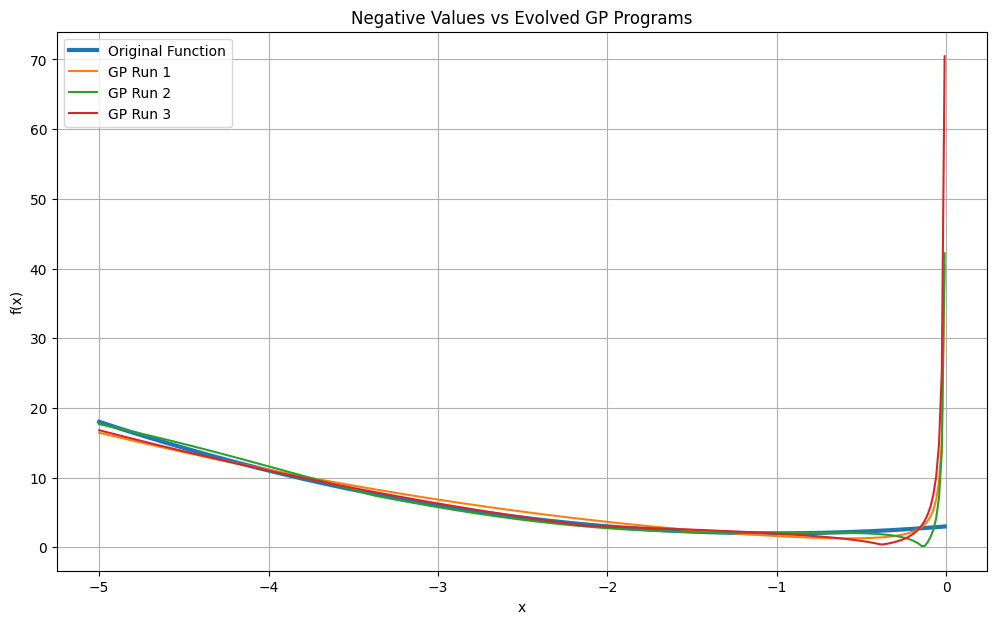

In [10]:
x_negative = np.linspace(-5, -0.01, 300)
plot_area("Negative Values vs Evolved GP Programs", x_negative)